# **Title: Bike Details Dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# name: Brand and model name of the bike
# selling_price: Listed selling price in INR
# year: Manufacturing year of the bike
# seller_type: Seller category, either "Individual" or "Dealer"
# owner: Ownership history, e.g., "1st owner", "2nd owner"
# km_driven: Total kilometers driven
# ex_showroom_price: Original showroom price in INR

In [ ]:
original_url = 'https://drive.google.com/file/d/1iKy23bMtEQShF_weneRNnYrFmzvpPOI3/view'
url = 'https://drive.google.com/uc?id=1iKy23bMtEQShF_weneRNnYrFmzvpPOI3'

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [ ]:
#Q1. What is the range of selling prices in the dataset?

lowest = df['selling_price'].min()
highest = df['selling_price'].max()
range = highest - lowest
print(range)

# lowest = df['selling_price'].sort_values().iloc[0]
# highest = df['selling_price'].sort_values(ascending=False).iloc[0]

755000


In [ ]:
#Q2. What is the median selling price for bikes in the dataset?

median = df['selling_price'].median()
print(median)

45000.0


In [ ]:
#Q3. What is the most common seller type?

most_common_seller_type = df['seller_type'].value_counts().index[0]
print(most_common_seller_type)
# df['seller_type'].value_counts().head(1)

Individual


In [ ]:
#Q4. How many bikes have driven more than 50,000 kilometers?

bikes_driven_more = (df['km_driven'] > 50000).sum()
print(bikes_driven_more)

170


In [ ]:
#Q5. What is the average km_driven value for each ownership type?

avg_km_driven = df.groupby('owner')['km_driven'].mean()
for owner, km in enumerate(avg_km_driven):
  print(f"Owner: {owner} | Km: {km}")

Owner: 0 | Km: 32816.583333333336
Owner: 1 | Km: 39288.9918699187
Owner: 2 | Km: 33292.181818181816
Owner: 3 | Km: 311500.0


In [ ]:
#Q6. What proportion of bikes are from the year 2015 or older?

proportion = (df['year'] < 2015).sum() / len(df)
print(proportion * 100)

47.219604147031106


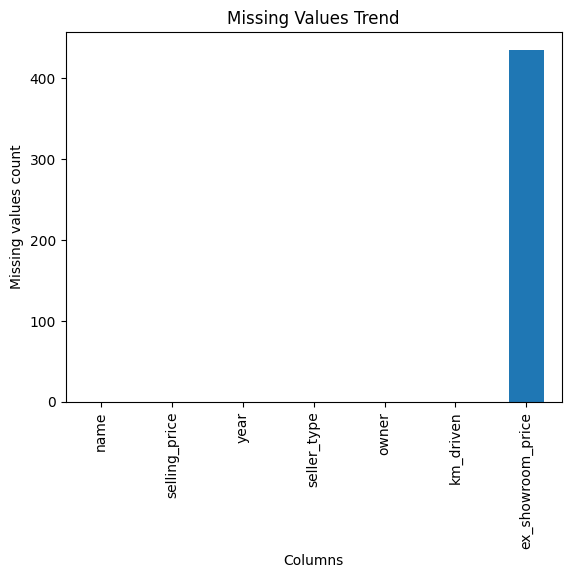

In [ ]:
#Q7. What is the trend of missing values across the dataset?

missing_value = df.isna().sum()

missing_value.plot(kind = 'bar')
plt.title('Missing Values Trend')
plt.xlabel('Columns')
plt.ylabel('Missing values count')
plt.show()

In [ ]:
#Q8. What is the highest ex_showroom_price recorded, and for which bike?

index = df['ex_showroom_price'].idxmax()
df.loc[index, ['name', 'ex_showroom_price']]

,134
name,Harley-Davidson Street Bob
ex_showroom_price,1278000.0


In [ ]:
#Q9.  What is the total number of bikes listed by each seller type?

seller_type_count = df['seller_type'].value_counts()
seller_type_count

,count
seller_type,
Individual,1055
Dealer,6


In [ ]:
df.owner.unique()

array(['1st owner', '2nd owner', '3rd owner', '4th owner'], dtype=object)

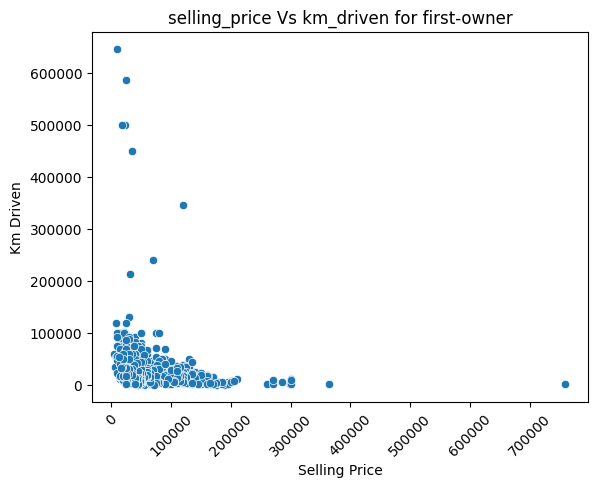

In [ ]:
#Q10. What is the relationship between selling_price and km_driven for first-owner bikes?

first_owner = df[df['owner'] == '1st owner']
sns.scatterplot(x = 'selling_price', y = 'km_driven', data = first_owner, palette = 'dark')
plt.title('selling_price Vs km_driven for first-owner')
plt.xticks(rotation = 45)
plt.xlabel('Selling Price')
plt.ylabel('Km Driven')
plt.show()

In [ ]:
#Q11. Identify and remove outliers in the km_driven column using the IQR method?

Q1 = df['km_driven'].quantile(0.25)
Q3 = df['km_driven'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['km_driven'] < lower_bound) | (df['km_driven'] > upper_bound)]
outliers

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
91,Honda Activa [2000-2015],22989,2012,Individual,1st owner,500000,50267.0
93,Suzuki GS150R,30000,2010,Individual,1st owner,130000,70851.0
115,Hero Honda Passion Plus,7500,2004,Individual,1st owner,120000,NaN
135,Hero Honda CBZ extreme,20000,2007,Individual,1st owner,90000,NaN
154,Hero Xtreme Sports,22000,2014,Individual,1st owner,99000,78350.0
184,Honda CB Unicorn 160,75000,2015,Individual,1st owner,100000,79233.0
363,Hero Honda CD100SS,10000,1997,Individual,1st owner,646000,NaN
470,Honda Activa [2000-2015],23000,2009,Individual,1st owner,95000,50267.0
474,Hero Honda Passion PRO [2012],12000,2012,Individual,1st owner,90000,NaN
477,Honda Activa [2000-2015],25000,2009,Individual,1st owner,585659,50267.0


In [ ]:
cleaned_df = df[(df['km_driven'] < lower_bound) | (df['km_driven'] > upper_bound)]
cleaned_df

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
91,Honda Activa [2000-2015],22989,2012,Individual,1st owner,500000,50267.0
93,Suzuki GS150R,30000,2010,Individual,1st owner,130000,70851.0
115,Hero Honda Passion Plus,7500,2004,Individual,1st owner,120000,NaN
135,Hero Honda CBZ extreme,20000,2007,Individual,1st owner,90000,NaN
154,Hero Xtreme Sports,22000,2014,Individual,1st owner,99000,78350.0
184,Honda CB Unicorn 160,75000,2015,Individual,1st owner,100000,79233.0
363,Hero Honda CD100SS,10000,1997,Individual,1st owner,646000,NaN
470,Honda Activa [2000-2015],23000,2009,Individual,1st owner,95000,50267.0
474,Hero Honda Passion PRO [2012],12000,2012,Individual,1st owner,90000,NaN
477,Honda Activa [2000-2015],25000,2009,Individual,1st owner,585659,50267.0


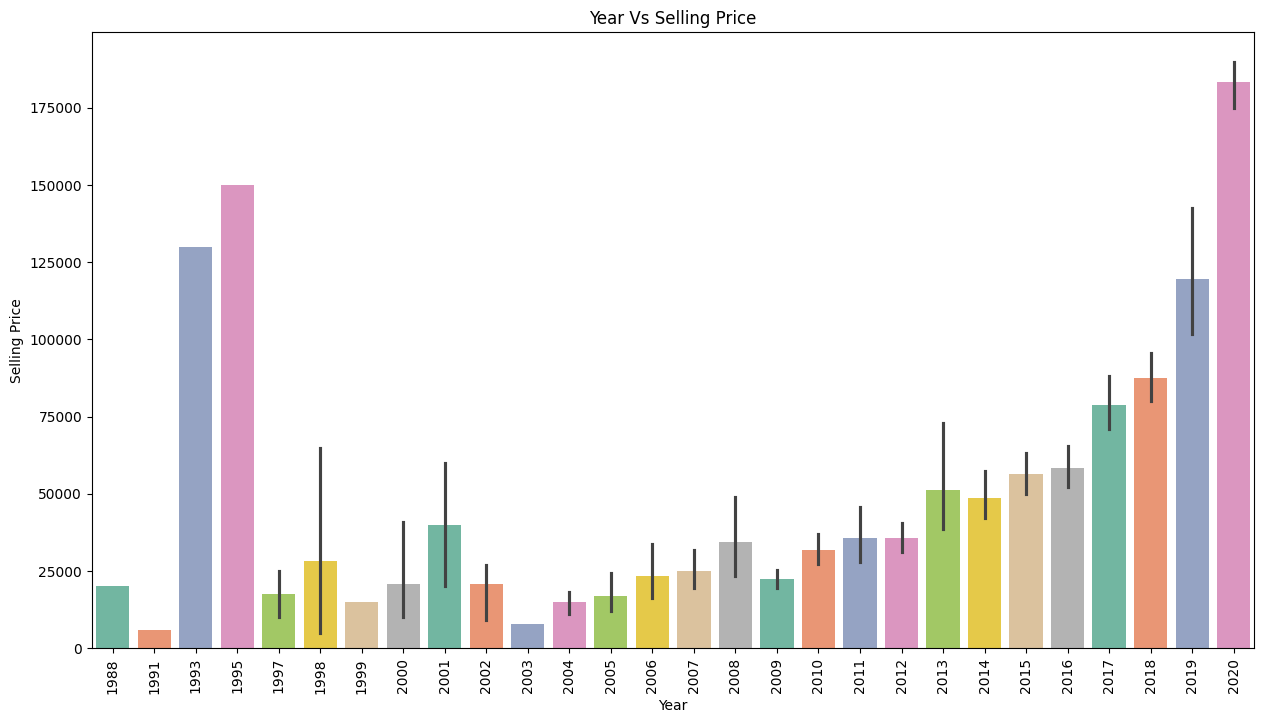

In [ ]:
#Q12.  Perform a bivariate analysis to visualize the relationship between year and selling_price.

plt.figure(figsize = (15,8))
sns.barplot(x = 'year', y = 'selling_price', data = df, palette = 'Set2')
plt.title('Year Vs Selling Price')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.xticks(rotation = 90)
# plt.yticks(rotation = 60)
plt.show()

In [ ]:
#Q13. What is the average depreciation in selling price based on the bike's age (current year - manufacturing year)?

current_year = 2025

# Calculate Bike Age
df['Bike_Age'] = current_year - df['year']

# Calculate Depreciation
df['Depreciation'] = df['ex_showroom_price'] - df['selling_price']

# Group by Age and compute averages
avg_depreciation = (df.groupby('Bike_Age')[['selling_price']].mean().reset_index())

avg_depreciation

,Bike_Age,selling_price
0,5,183333.333333
1,6,119689.511628
2,7,87660.374046
3,8,78894.736842
4,9,58469.018692
5,10,56500.000000
6,11,48668.131868
7,12,51136.986301
8,13,35748.400000
9,14,35655.721311


In [ ]:
#Q14. Which bike names are priced significantly above the average price for their manufacturing year?

bikes = df[df['selling_price'] > 1.3 * df.groupby('year')['selling_price'].transform('mean')]['name'].unique()
for bike in bikes:
  print(bike)

Royal Enfield Classic 350
Royal Enfield Classic Gunmetal Grey
Royal Enfield Bullet 350 [2007-2011]
Yamaha YZF R3
Yamaha FZ25
Jawa Standard
Royal Enfield Thunderbird 350
Honda CBR-250R
Bajaj Dominar 400
KTM 390 Duke
Yamaha FZ16
Royal Enfield Electra 5 S
Royal Enfield Bullet 350
Royal Enfield Electra 4 S
Mahindra Mojo XT300
Royal Enfield Thunderbird 350X
Hero Honda Karizma ZMR [2010]
Royal Enfield Classic Desert Storm
UM Renegade Commando
Royal Enfield Continental GT 650
Harley-Davidson Street Bob
KTM 390 Duke ABS [2013-2016]
KTM 200 Duke
Royal Enfield Classic 500
KTM RC 390
Bajaj Pulsar 150
KTM RC 200
Honda CB Unicorn 160
Honda CB Unicorn 150
Royal Enfield Bullet 500
Bajaj Dominar 400 [2018]
Royal Enfield Interceptor 650
Bajaj Avenger Street 220
Royal Enfield Machismo
Hero Honda CBZ extreme
KTM 250 Duke
Kawasaki Ninja 650 [2018-2019]
Kawasaki Ninja 250R
Suzuki GSX S750
Yamaha Rx
Yamaha Fazer Dlx
Harley-Davidson Street 750
TVS Apache RR310
Yamaha YZF R15 V3
BMW G310GS
Royal Enfield Thund

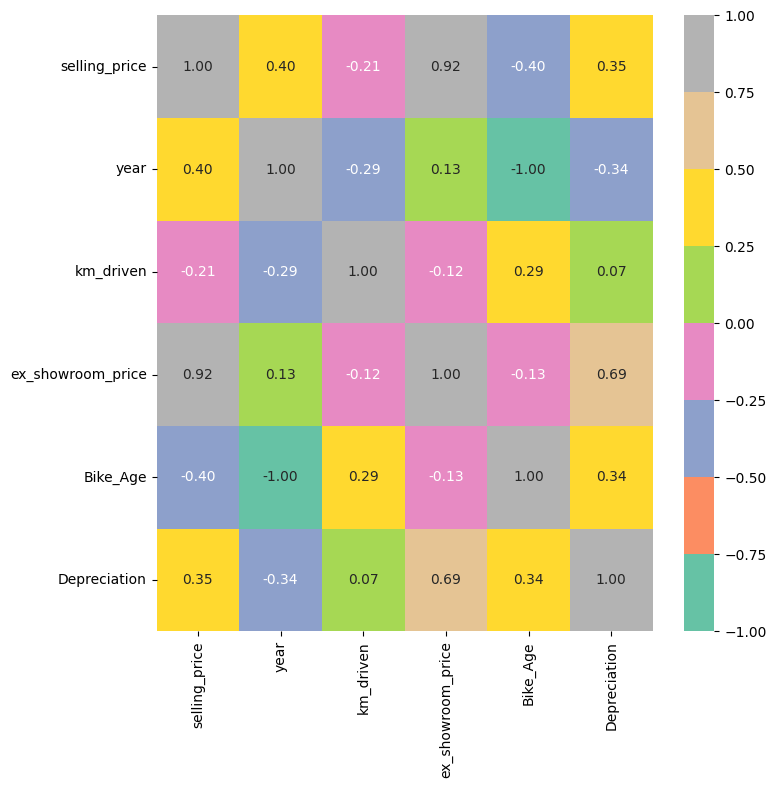

In [ ]:
#Q15. Develop a correlation matrix for numeric columns and visualize it using a heatmap.

# num_features = [feature for feature in df.columns if df[feature].dtypes != 'object']
corr = df.corr(numeric_only= True)

plt.figure(figsize = (8,8))
sns.heatmap(corr, annot = True, cmap = 'Set2', fmt = '.2f')
plt.show()

In [ ]:
pip install nbmerge

  Preparing metadata (setup.py) ... done
  Created wheel for nbmerge: filename=nbmerge-0.0.4-py2.py3-none-any.whl size=6396 sha256=352ae7029ed36f94c2b0380715ed5bc966ab64b6d5c8a00ec374204439cac3f8
  Stored in directory: /root/.cache/pip/wheels/66/ec/e3/e3e9f9c3007f764582fcd1d93e2c9d296355985422f62c55f1
Successfully built nbmerge


In [7]:
!nbmerge "EDA_1_Bike_Details_Dataset.ipynb" "EDA_2_Car_Sale_Dataset.ipynb" "EDA_3_Amazon Sales Data.ipynb" "EDA_4_Spotify_Data.ipynb" > "EDA.ipynb"

Traceback (most recent call last):
  File "/usr/local/bin/nbmerge", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nbmerge/__init__.py", line 189, in main
    plan = parse_plan(args)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nbmerge/__init__.py", line 173, in parse_plan
    raise IOError("Notebook `{}` does not exist".format(file_path))
OSError: Notebook `EDA_1_Bike_Details_Dataset.ipynb` does not exist


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
url = 'https://drive.google.com/uc?id=1N0kM_zi-iU3yvr6BEJf21aiF599PtA0U'

In [ ]:
pip install nbmerge

  Preparing metadata (setup.py) ... done
  Created wheel for nbmerge: filename=nbmerge-0.0.4-py2.py3-none-any.whl size=6396 sha256=dbfb482a792f13bc05d3c82b1eef760d33e58c94fdfbcf9e9b98ab7bf2093834
  Stored in directory: /root/.cache/pip/wheels/66/ec/e3/e3e9f9c3007f764582fcd1d93e2c9d296355985422f62c55f1
Successfully built nbmerge


In [12]:
!nbmerge "EDA_1_Bike_Details_Dataset.ipynb" "EDA_2_Car_Sale_Dataset.ipynb" "EDA_3_Amazon_Sales_Data.ipynb" "EDA_4_Spotify_Data.ipynb" > "eda.ipynb"

Traceback (most recent call last):
  File "/usr/local/bin/nbmerge", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nbmerge/__init__.py", line 189, in main
    plan = parse_plan(args)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/nbmerge/__init__.py", line 173, in parse_plan
    raise IOError("Notebook `{}` does not exist".format(file_path))
OSError: Notebook `EDA_1_Bike_Details_Dataset.ipynb` does not exist


In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [ ]:
# Car_id: A unique identifier for each car in the dataset, helping to track individual car entries.
# Date: The date when the car sale transaction took place, formatted as YYYY-MM-DD.
# Customer Name: The name of the customer who purchased the car, represented as a string.
# Gender: The gender of the customer, categorized as "Male" or "Female.
# Annual Income: The customer's annual income in US dollars, represented as a numeric value.
# Dealer_Name: The name of the dealership selling the car, represented as a string.
# Company: The manufacturer or brand name of the car, such as "Toyota," "Ford," etc.
# Model: The specific model name of the car, such as "Corolla," "Civic," etc.
# Engine: The engine type of the car, such as "V6," "I4," etc.
# Transmission: The type of transmission in the car, either "Manual" or "Automatic.
# Color: The color of the car, represented as a string (e.g., "Red," "Blue").
# Price ($): The selling price of the car in US dollars.
# Dealer_No: A unique identifier for each car dealer in the dataset.
# Body Style: The body style of the car, such as "Sedan," "SUV," etc.
# Phone: The phone number of the customer who purchased the car.
# Dealer_Region: The geographical region of the car dealer, such as "North," "South," etc.

In [ ]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [ ]:
df['Price'] = df['Price ($)']

In [ ]:
df.drop('Price ($)', axis = 1, inplace = True)

In [ ]:
df['Dealer_No'] = df['Dealer_No ']
df.drop('Dealer_No ', axis = 1, inplace = True)

In [ ]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Body Style', 'Phone', 'Dealer_Region', 'Price', 'Dealer_No'],
      dtype='object')

In [ ]:
#Q1. What is the average selling price of cars for each dealer, and how does it compare across different dealers?

avg_selling_price = df.groupby('Dealer_No')['Price'].mean().reset_index()
avg_selling_price

,Dealer_No,Price
0,06457-3834,27771.614943
1,38701-8047,28208.618455
2,53546-9427,28009.712038
3,60504-7114,28134.025879
4,78758-7841,28272.412204
5,85257-3102,28259.141059
6,99301-3882,27920.853768


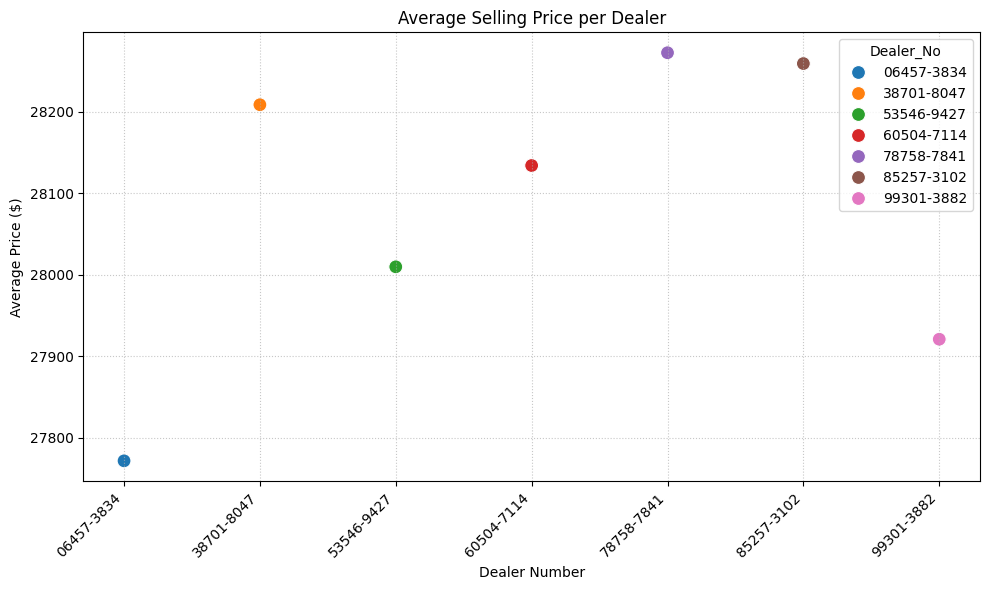

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=avg_selling_price, x='Dealer_No', y='Price', hue='Dealer_No', s=100, legend='full')
plt.title('Average Selling Price per Dealer')
plt.xlabel('Dealer Number')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#Q2. Which car brand (Company) has the highest variation in prices, and what does this tell us about the pricing trends?

company_price_std = df.groupby('Company')['Price'].std().reset_index()
company_price_std

,Company,Price
0,Acura,8183.046414
1,Audi,12904.243867
2,BMW,15065.578723
3,Buick,17142.232626
4,Cadillac,19517.120220
5,Chevrolet,13311.063223
6,Chrysler,11583.286811
7,Dodge,11187.592085
8,Ford,15849.090227
9,Honda,11148.629062


In [ ]:
company_with_highest_std = company_price_std.loc[company_price_std['Price'].idxmax()]
company_with_highest_std

,15
Company,Lincoln
Price,19658.050211


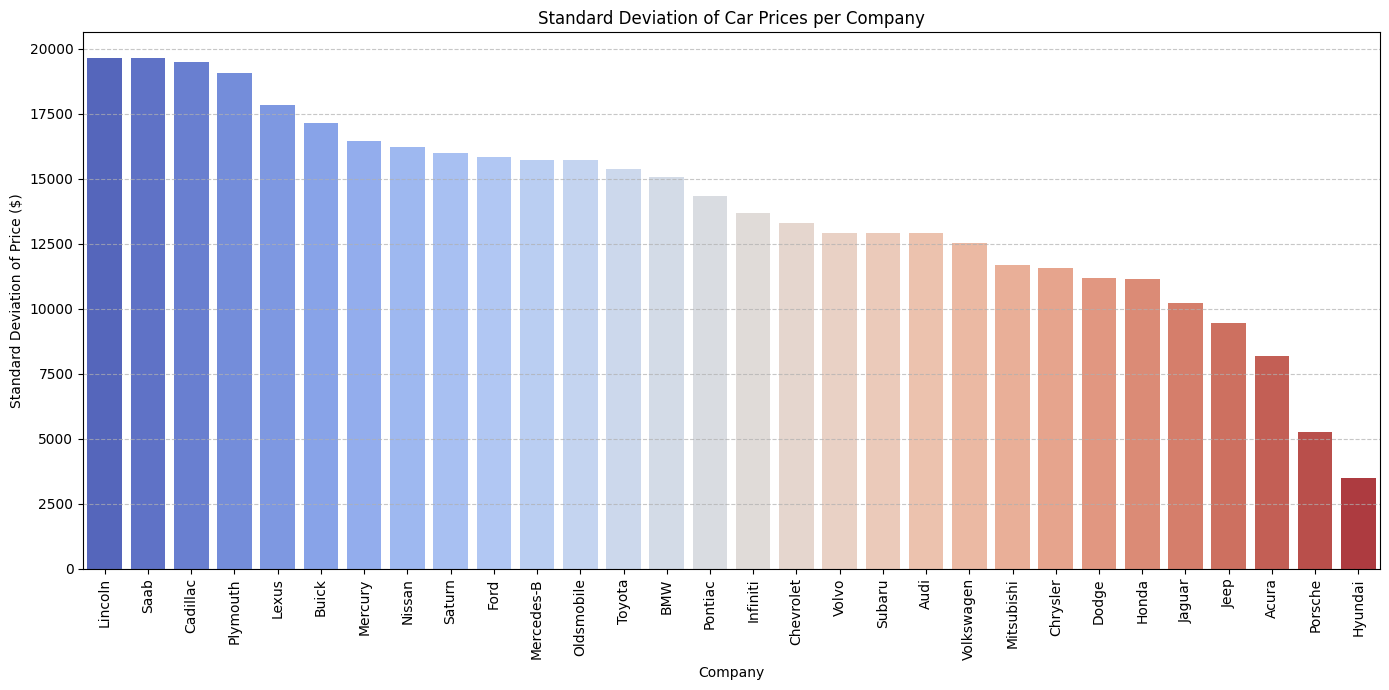

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Company', y='Price', data=company_price_std.sort_values(by='Price', ascending=False), palette='coolwarm')
plt.title('Standard Deviation of Car Prices per Company')
plt.xlabel('Company')
plt.ylabel('Standard Deviation of Price ($)')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

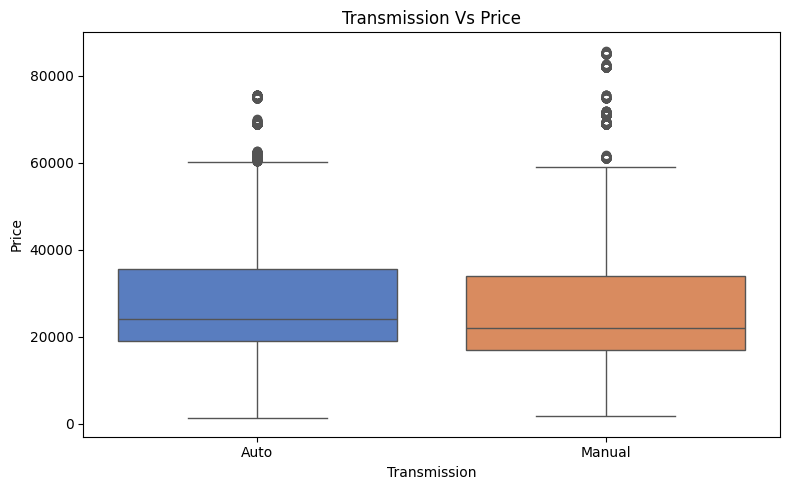

In [ ]:
#Q3. What is the distribution of car prices for each transmission type, and how do the interquartile ranges compare?

plt.figure(figsize=(8, 5))
sns.boxplot(x = 'Transmission', y = 'Price', data = df, palette = 'muted')
plt.title('Transmission Vs Price')
plt.xlabel('Transmission')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Price')

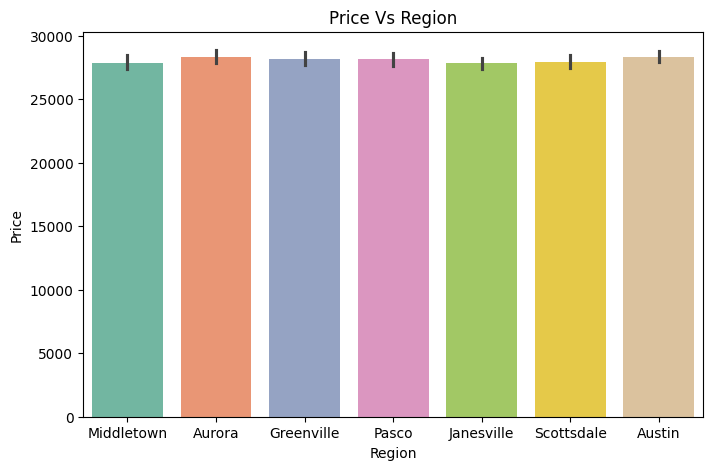

In [ ]:
#Q4. What is the distribution of car prices across different regions?

plt.figure(figsize = (8,5))
sns.barplot(x = 'Dealer_Region', y = 'Price', data = df, palette = 'Set2')
plt.title('Price Vs Region')
plt.xlabel('Region')
plt.ylabel('Price')

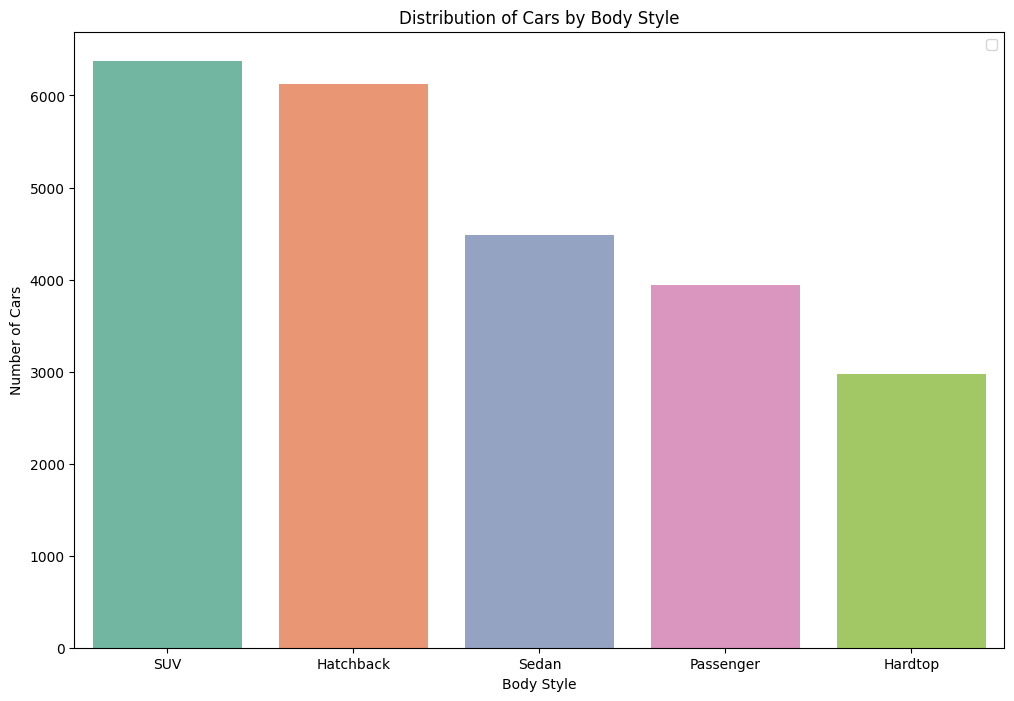

In [ ]:
#Q5. What is the distribution of cars based on body styles?

plt.figure(figsize=(12,8))
sns.countplot(x = 'Body Style', data=df, order=df['Body Style'].value_counts().index, palette='Set2')
plt.xlabel('Body Style')
plt.ylabel('Number of Cars')
plt.title('Distribution of Cars by Body Style')
plt.legend()
plt.show()

<Axes: xlabel='Price', ylabel='Annual Income'>

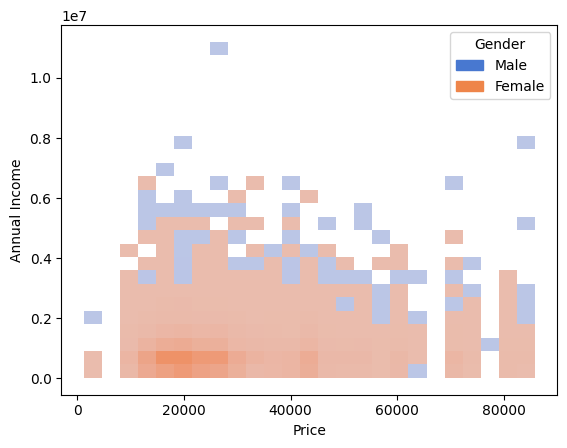

In [ ]:
#6. How does the average selling price of cars vary by customer gender and annual income?

sns.histplot(x = 'Price', y = 'Annual Income', bins = 25, data = df, hue = 'Gender', palette = 'muted')

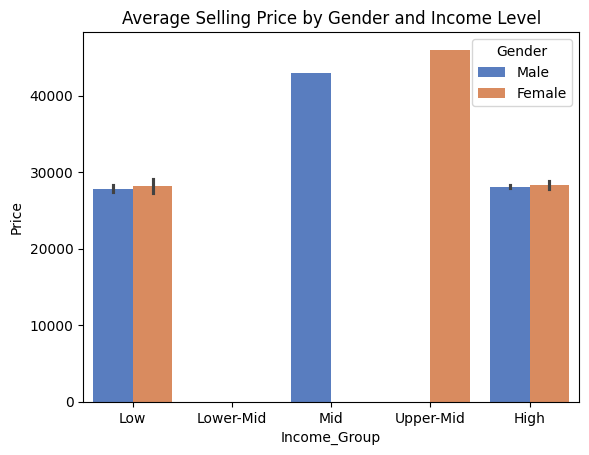

In [ ]:
df['Income_Group'] = pd.cut(
    df['Annual Income'],
    bins=[0, 30000, 60000, 90000, 120000, df['Annual Income'].max()],
    labels=['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High']
)

sns.barplot(
    x='Income_Group',
    y='Price',
    hue='Gender',
    data=df,
    palette='muted'
)

plt.title('Average Selling Price by Gender and Income Level')
plt.show()


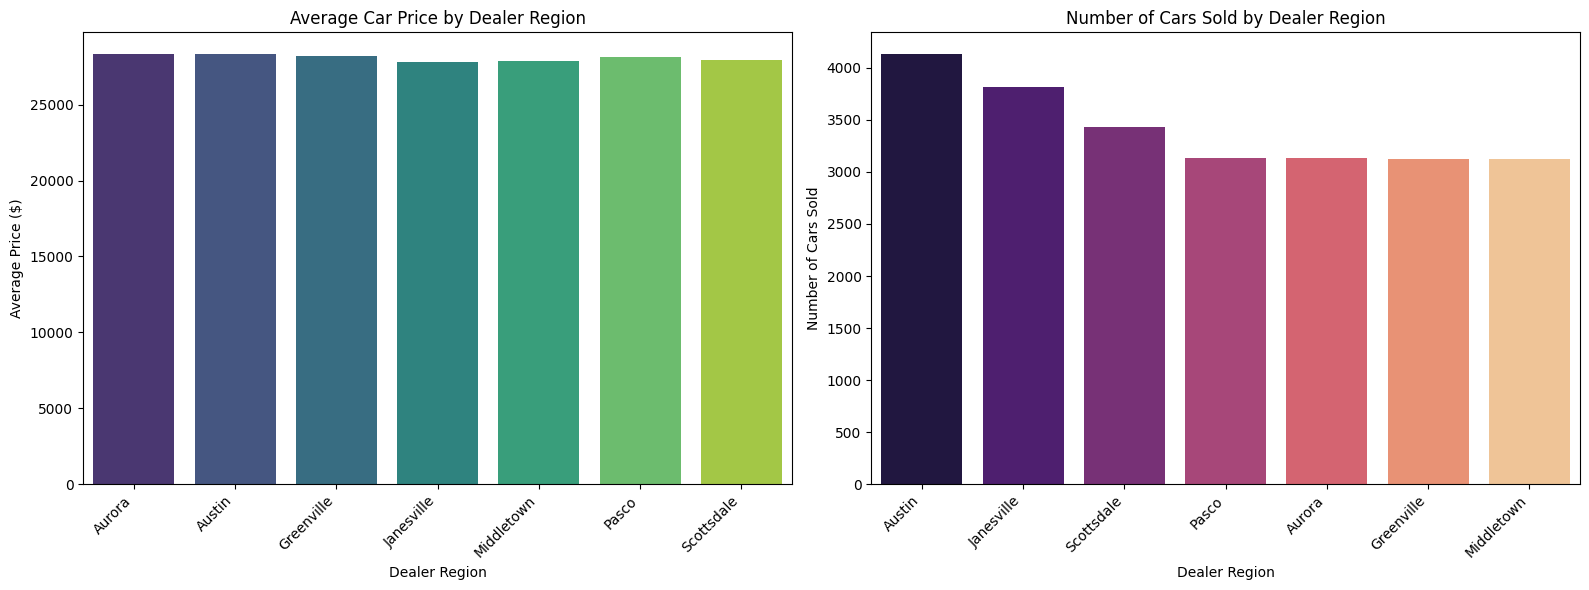

In [ ]:
#Q7. What is the distribution of car prices by region, and how does the number of cars sold vary by region?

avg_price_by_region = df.groupby('Dealer_Region')['Price'].mean().reset_index()

# Calculate number of cars sold by region
cars_sold_by_region = df['Dealer_Region'].value_counts().reset_index()
cars_sold_by_region.columns = ['Dealer_Region', 'Number of Cars Sold']

plt.figure(figsize = (16, 6))

# Subplot 1: Distribution of car prices by region
plt.subplot(1, 2, 1)
sns.barplot(x = 'Dealer_Region', y = 'Price', data = avg_price_by_region, palette = 'viridis')
plt.title('Average Car Price by Dealer Region')
plt.xlabel('Dealer Region')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45, ha='right')

# Subplot 2: Number of cars sold by region
plt.subplot(1, 2, 2)
sns.barplot(x = 'Dealer_Region', y = 'Number of Cars Sold', data = cars_sold_by_region, palette = 'magma')
plt.title('Number of Cars Sold by Dealer Region')
plt.xlabel('Dealer Region')
plt.ylabel('Number of Cars Sold')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

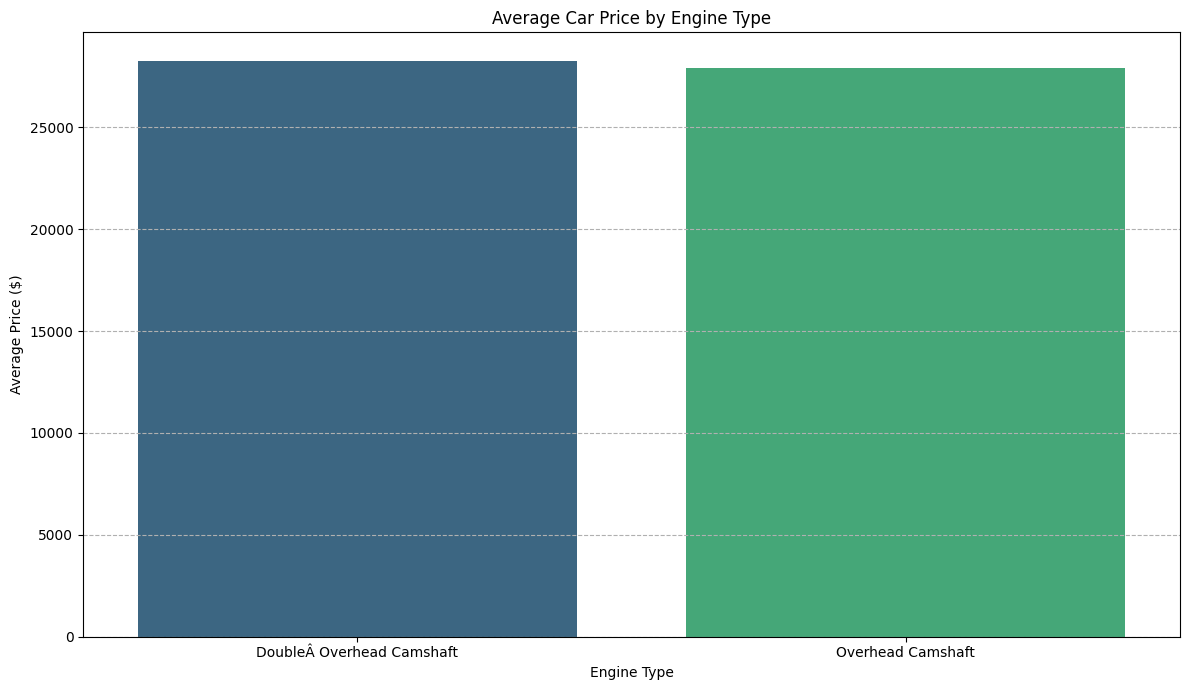

In [ ]:
#Q8. How does the average car price differ between cars with different engine sizes?

avg_price_by_engine = df.groupby('Engine')['Price'].mean().reset_index()

avg_price_by_engine = avg_price_by_engine.sort_values(by='Price', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='Engine', y='Price', data=avg_price_by_engine, palette='viridis')
plt.title('Average Car Price by Engine Type')
plt.xlabel('Engine Type')
plt.ylabel('Average Price ($)')
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

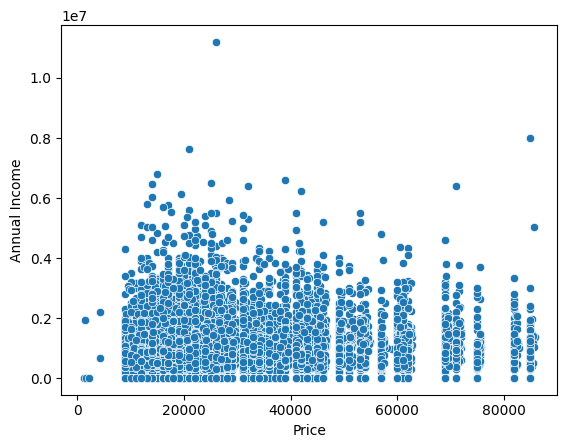

In [ ]:
#Q9. How do car prices vary based on the customer’s annual income bracket?

sns.scatterplot(x = 'Price', y = 'Annual Income', data = df, palette = 'magma')
plt.show()

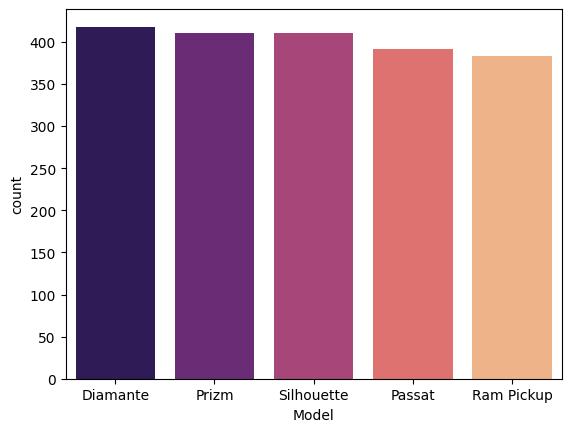

In [ ]:
#Q10. What are the top 5 car models with the highest number of sales, and how does their price distribution look?

top_5_models = df['Model'].value_counts().head(5).reset_index()
sns.barplot(x = 'Model', y = 'count', data = top_5_models, palette = 'magma')
plt.show()

In [ ]:
from scipy.stats import f_oneway

anova_data = [
    top_models_df[top_models_df['Model'] == model]['Price']
    for model in top_5_models.index
]

f_stat, p_value = f_oneway(*anova_data)

f_stat, p_value


(np.float64(nan), np.float64(nan))

In [ ]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Body Style', 'Phone', 'Dealer_Region', 'Price', 'Dealer_No',
       'Income_Group'],
      dtype='object')

In [ ]:
df.Engine.unique()

array(['DoubleÂ\xa0Overhead Camshaft', 'Overhead Camshaft'], dtype=object)

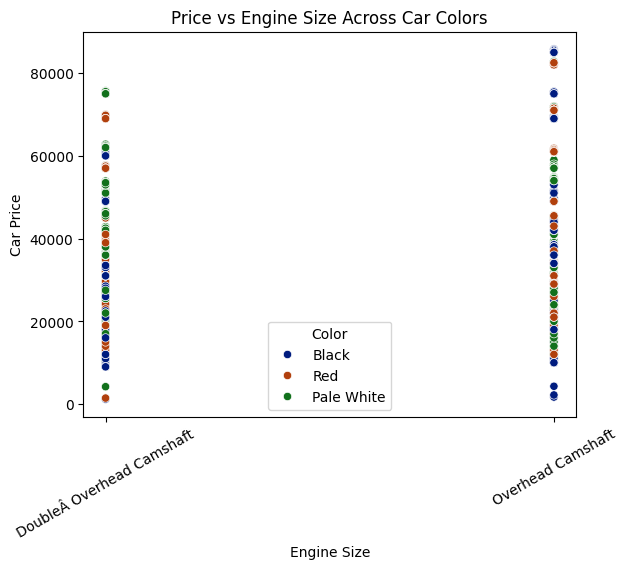

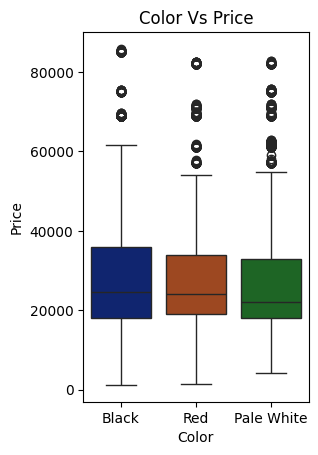

In [ ]:
#Q11. How does car price vary with engine size across different car colors, and which colors have the highest price variation?

plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.scatterplot(x = 'Engine', y = 'Price', data = df, hue = 'Color', palette = 'dark')
plt.xlabel('Engine Size')
plt.ylabel('Car Price')
plt.xticks(rotation = 30)
plt.title('Price vs Engine Size Across Car Colors')
plt.show()

plt.subplot(1,2,2)
sns.boxplot(x = 'Color', y = 'Price', data = df, palette = 'dark')
plt.title('Color Vs Price')
plt.xlabel('Color')
plt.ylabel('Price')
plt.show()

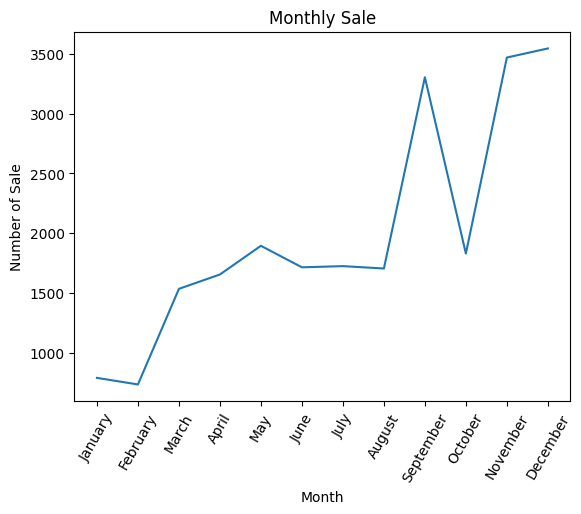

In [ ]:
#Q12. Is there any seasonal trend in car sales based on the date of sale?

df['Date'] = pd.to_datetime(df['Date'])
df['Month_Name'] = df['Date'].dt.month_name()
monthly_sales = df.groupby('Month_Name')['Car_id'].count().reindex([
    'January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']).reset_index()

plt.figure()
sns.lineplot(x = 'Month_Name', y = 'Car_id', data = monthly_sales, palette = 'coolwarm')
plt.title('Monthly Sale')
plt.xlabel('Month')
plt.xticks(rotation = 60)
plt.ylabel('Number of Sale')
plt.show()

In [ ]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Body Style', 'Phone', 'Dealer_Region', 'Price', 'Dealer_No',
       'Income_Group', 'Data', 'Monthly_Name', 'Month_Name'],
      dtype='object')

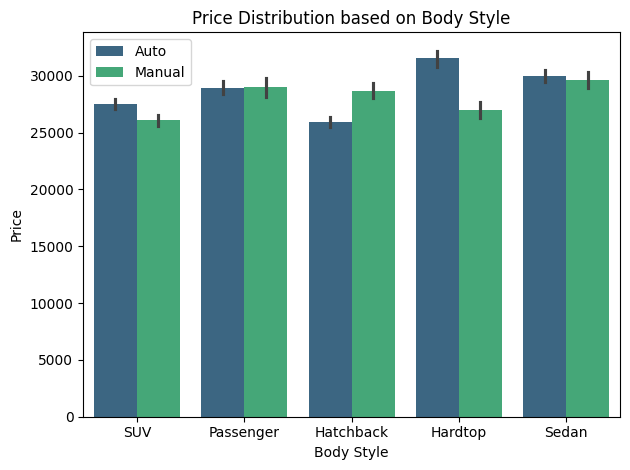

In [ ]:
#Q13. How does the car price distribution change when considering different combinations of body style and transmission type?

sns.barplot(x = 'Body Style', y = 'Price', hue = 'Transmission', data = df, palette = 'viridis')
plt.title('Price Distribution based on Body Style')
plt.xlabel('Body Style')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

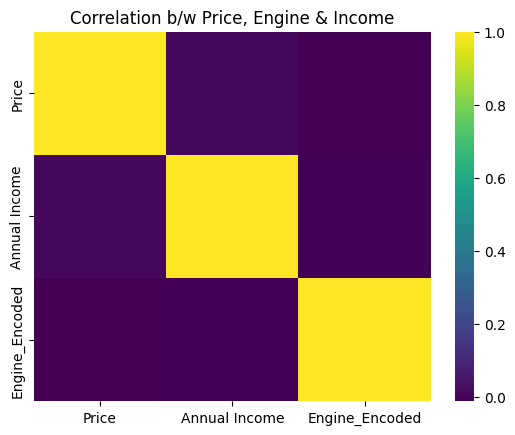

In [ ]:
#Q14. What is the correlation between car price, engine size, and annual income of customers, and how do these features interact?

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df['Engine_Encoded'] = encoder.fit_transform(df[['Engine']])

corr = df[['Price', 'Annual Income', 'Engine_Encoded']].corr()

sns.heatmap(corr, cmap = 'viridis', fmt = '.2f')
plt.title('Correlation b/w Price, Engine & Income')
plt.show()

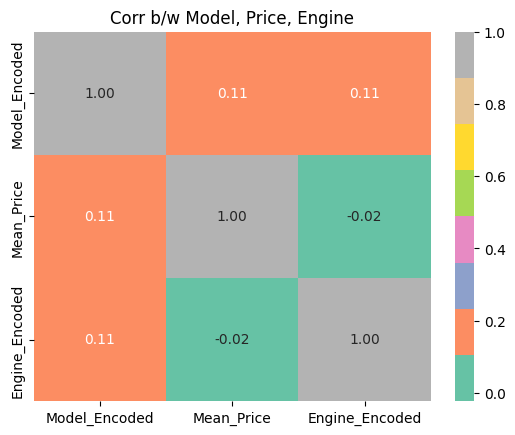

In [ ]:
#Q15. How does the average car price vary across different car models and engine types?

df['Model_Encoded'] = encoder.fit_transform(df[['Model']])
df['Mean_Price'] = df.groupby('Model')['Price'].transform('mean')

corr = df[['Model_Encoded', 'Mean_Price', 'Engine_Encoded']].corr()
plt.title('Corr b/w Model, Price, Engine')
sns.heatmap(corr, annot = True, cmap = 'Set2', fmt = '.2f')
plt.show()

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://drive.google.com/uc?id=1yKlW0x5yyRQijmWbEg5YCsq4wqLl3_oB'

In [3]:
df = pd.read_csv(url)

In [4]:
df.head(5)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [6]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [7]:
df['product_name']

,product_name
0,Wayona Nylon Braided USB to Lightning Fast Cha...
1,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...
2,Sounce Fast Phone Charging Cable & Data Sync U...
3,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...
4,Portronics Konnect L 1.2M Fast Charging 3A 8 P...
...,...
1460,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...
1461,Prestige Delight PRWO Electric Rice Cooker (1 ...
1462,Bajaj Majesty RX10 2000 Watts Heat Convector R...
1463,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...


In [8]:
df['category']

,category
0,Computers&Accessories|Accessories&Peripherals|...
1,Computers&Accessories|Accessories&Peripherals|...
2,Computers&Accessories|Accessories&Peripherals|...
3,Computers&Accessories|Accessories&Peripherals|...
4,Computers&Accessories|Accessories&Peripherals|...
...,...
1460,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...
1461,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...
1462,"Home&Kitchen|Heating,Cooling&AirQuality|RoomHe..."
1463,"Home&Kitchen|Heating,Cooling&AirQuality|Fans|E..."


In [9]:
df['discounted_price'] = df['discounted_price'].str.replace('₹','')
df['discounted_price'] = df['discounted_price'].str.replace(',', '')
df['discounted_price'] = df['discounted_price'].str.strip('.')

In [10]:
df['discounted_price'] = df['discounted_price'].astype(float)

In [11]:
df['actual_price'] = df['actual_price'].str.replace('₹','')
df['actual_price'] = df['actual_price'].str.replace(',','')
df['actual_price'] = df['actual_price'].str.strip('.')
df['actual_price'] = df['actual_price'].astype(float)

In [12]:
df['discount_percentage'].unique()

array(['64%', '43%', '90%', '53%', '61%', '85%', '65%', '23%', '50%',
       '33%', '55%', '63%', '69%', '60%', '13%', '44%', '38%', '39%',
       '46%', '41%', '70%', '42%', '72%', '25%', '51%', '73%', '0%',
       '80%', '28%', '67%', '58%', '35%', '45%', '62%', '54%', '27%',
       '77%', '56%', '78%', '31%', '86%', '47%', '37%', '75%', '32%',
       '68%', '66%', '22%', '57%', '17%', '52%', '88%', '20%', '59%',
       '40%', '26%', '29%', '83%', '71%', '15%', '76%', '48%', '82%',
       '36%', '89%', '87%', '24%', '34%', '11%', '91%', '7%', '19%',
       '79%', '21%', '81%', '18%', '49%', '30%', '84%', '10%', '6%',
       '14%', '74%', '4%', '5%', '16%', '8%', '2%', '94%', '12%', '3%',
       '9%'], dtype=object)

In [13]:
df['discount_percentage'] = df['discount_percentage'].str.replace('%','')
df['discount_percentage'] = df['discount_percentage'].astype(float)

In [14]:
df['rating'].unique()

array(['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [15]:
df['rating'].unique()

array(['4.2', '4.0', '3.9', '4.1', '4.3', '4.4', '4.5', '3.7', '3.3',
       '3.6', '3.4', '3.8', '3.5', '4.6', '3.2', '5.0', '4.7', '3.0',
       '2.8', '4', '3.1', '4.8', '2.3', '|', '2', '3', '2.6', '2.9'],
      dtype=object)

In [16]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

In [17]:
df['rating'].unique()

array([4.2, 4. , 3.9, 4.1, 4.3, 4.4, 4.5, 3.7, 3.3, 3.6, 3.4, 3.8, 3.5,
       4.6, 3.2, 5. , 4.7, 3. , 2.8, 3.1, 4.8, 2.3, nan, 2. , 2.6, 2.9])

In [18]:
df['rating'] = df['rating'].fillna(df['rating'].median())

In [19]:
df['rating'].unique()

array([4.2, 4. , 3.9, 4.1, 4.3, 4.4, 4.5, 3.7, 3.3, 3.6, 3.4, 3.8, 3.5,
       4.6, 3.2, 5. , 4.7, 3. , 2.8, 3.1, 4.8, 2.3, 2. , 2.6, 2.9])

In [20]:
df['rating_count'].unique()

array(['24,269', '43,994', '7,928', ..., '468', '8,031', '6,987'],
      dtype=object)

In [21]:
df['rating_count'] = df['rating_count'].str.replace(',','')
df['rating_count'] = pd.to_numeric(df['rating_count'], errors = 'coerce')

In [22]:
df['rating_count'].unique()

array([24269., 43994.,  7928., ...,   468.,  8031.,  6987.])

In [23]:
df['category'].unique()

array(['Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables',
       'Computers&Accessories|NetworkingDevices|NetworkAdapters|WirelessUSBAdapters',
       'Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables',
       'Electronics|HomeTheater,TV&Video|Televisions|SmartTelevisions',
       'Electronics|HomeTheater,TV&Video|Accessories|RemoteControls',
       'Electronics|HomeTheater,TV&Video|Televisions|StandardTelevisions',
       'Electronics|HomeTheater,TV&Video|Accessories|TVMounts,Stands&Turntables|TVWall&CeilingMounts',
       'Electronics|HomeTheater,TV&Video|Accessories|Cables|RCACables',
       'Electronics|HomeAudio|Accessories|SpeakerAccessories|Mounts',
       'Electronics|HomeTheater,TV&Video|Accessories|Cables|OpticalCables',
       'Electronics|HomeTheater,TV&Video|Projectors',
       'Electronics|HomeAudio|Accessories|Adapters',
       'Electronics|HomeTheater,TV&Video|SatelliteEquipment|SatelliteReceivers',
       'Computers&Acces

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           1465 non-null   object 
 1   product_name         1465 non-null   object 
 2   category             1465 non-null   object 
 3   discounted_price     1465 non-null   float64
 4   actual_price         1465 non-null   float64
 5   discount_percentage  1465 non-null   float64
 6   rating               1465 non-null   float64
 7   rating_count         1463 non-null   float64
 8   about_product        1465 non-null   object 
 9   user_id              1465 non-null   object 
 10  user_name            1465 non-null   object 
 11  review_id            1465 non-null   object 
 12  review_title         1465 non-null   object 
 13  review_content       1465 non-null   object 
 14  img_link             1465 non-null   object 
 15  product_link         1465 non-null   o

In [25]:
df

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,199.0,349.0,43.0,4.0,43994.0,"Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,199.0,1899.0,90.0,3.9,7928.0,【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,329.0,699.0,53.0,4.2,94363.0,The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,154.0,399.0,61.0,4.2,16905.0,[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1460,B08L7J3T31,Noir Aqua - 5pcs PP Spun Filter + 1 Spanner | ...,Home&Kitchen|Kitchen&HomeAppliances|WaterPurif...,379.0,919.0,59.0,4.0,1090.0,SUPREME QUALITY 90 GRAM 3 LAYER THIK PP SPUN F...,"AHITFY6AHALOFOHOZEOC6XBP4FEA,AFRABBODZJZQB6Z4U...","Prabha ds,Raghuram bk,Real Deal,Amazon Custome...","R3G3XFHPBFF0E8,R3C0BZCD32EIGW,R2EBVBCN9QPD9R,R...","Received the product without spanner,Excellent...","I received product without spanner,Excellent p...",https://m.media-amazon.com/images/I/41fDdRtjfx...,https://www.amazon.in/Noir-Aqua-Spanner-Purifi...
1461,B01M6453MB,Prestige Delight PRWO Electric Rice Cooker (1 ...,Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...,2280.0,3045.0,25.0,4.1,4118.0,"230 Volts, 400 watts, 1 Year","AFG5FM3NEMOL6BNFRV2NK5FNJCHQ,AGEINTRN6Z563RMLH...","Manu Bhai,Naveenpittu,Evatira Sangma,JAGANNADH...","R3DDL2UPKQ2CK9,R2SYYU1OATVIU5,R1VM993161IYRW,R...","ok,everything was good couldn't return bcoz I ...","ok,got everything as mentioned but th

In [26]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [27]:
#Q1. What is the average rating for each product category?

df.groupby('category')['rating'].mean().reset_index()

,category,rating
0,Car&Motorbike|CarAccessories|InteriorAccessori...,3.800000
1,Computers&Accessories|Accessories&Peripherals|...,4.150000
2,Computers&Accessories|Accessories&Peripherals|...,3.500000
3,Computers&Accessories|Accessories&Peripherals|...,3.600000
4,Computers&Accessories|Accessories&Peripherals|...,4.050000
...,...,...
206,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.250000
207,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.150000
208,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.300000
209,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.133333


In [28]:
#Q2. What are the top rating_count products by category?

df.groupby('category')['rating_count'].idxmax().reset_index()

,category,rating_count
0,Car&Motorbike|CarAccessories|InteriorAccessori...,1157
1,Computers&Accessories|Accessories&Peripherals|...,695
2,Computers&Accessories|Accessories&Peripherals|...,906
3,Computers&Accessories|Accessories&Peripherals|...,748
4,Computers&Accessories|Accessories&Peripherals|...,844
...,...,...
206,OfficeProducts|OfficePaperProducts|Paper|Stati...,616
207,OfficeProducts|OfficePaperProducts|Paper|Stati...,993
208,OfficeProducts|OfficePaperProducts|Paper|Stati...,765
209,OfficeProducts|OfficePaperProducts|Paper|Stati...,850


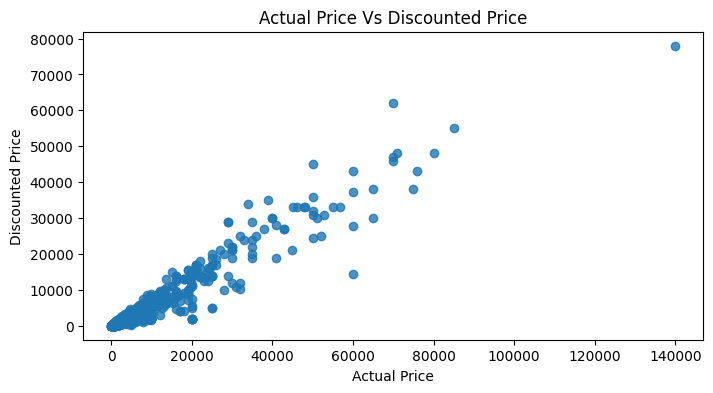

In [29]:
#Q3. What is the distribution of discounted prices vs. actual prices?

plt.figure(figsize=(8, 4))
plt.scatter(df['actual_price'],df['discounted_price'], alpha= 0.8)
plt.title('Actual Price Vs Discounted Price')
plt.xlabel('Actual Price')
plt.ylabel('Discounted Price')
plt.show()

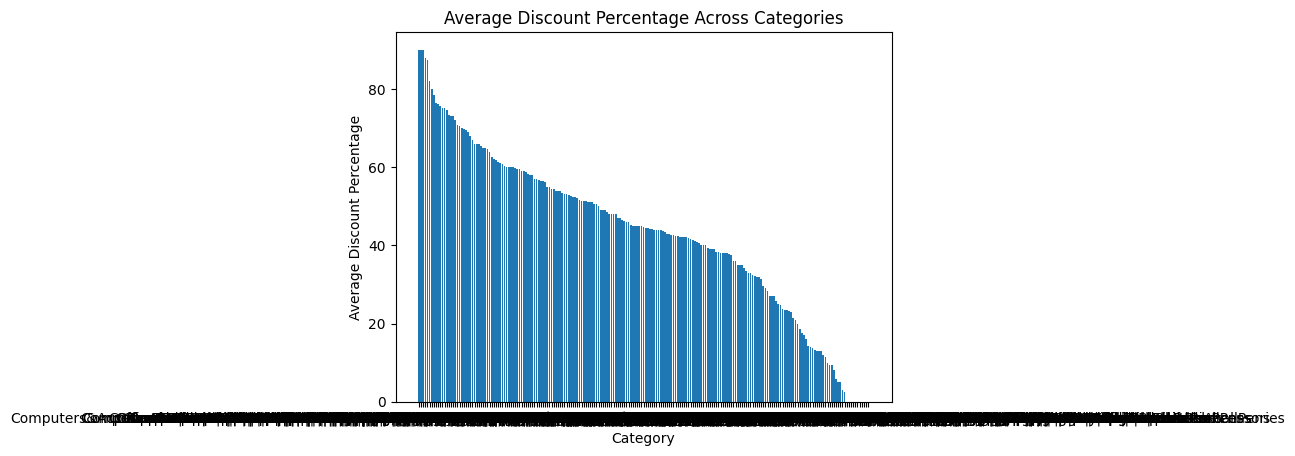

In [30]:
#Q4. How does the average discount percentage vary across categories?

avg_discount_category = df.groupby('category')['discount_percentage'].mean().sort_values(ascending= False)
plt.bar(
    avg_discount_category.index,
    avg_discount_category.values
)
plt.xlabel('Category')
plt.ylabel('Average Discount Percentage')
plt.title('Average Discount Percentage Across Categories')
plt.tight_layout()
plt.show()

In [33]:
#Q5. What are the most popular product names?

df['product_name'].value_counts().reset_index().head(5)

,product_name,count
0,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
1,Fire-Boltt Phoenix Smart Watch with Bluetooth ...,4
2,Amazonbasics Nylon Braided Usb-C To Lightning ...,3
3,Duracell USB Lightning Apple Certified (Mfi) B...,3
4,Flix Micro Usb Cable For Smartphone (Black),3


In [34]:
df.columns

Index(['product_id', 'product_name', 'category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'about_product', 'user_id', 'user_name', 'review_id', 'review_title',
       'review_content', 'img_link', 'product_link'],
      dtype='object')

In [35]:
#Q6. What are the most popular product keywords?

df['product_name'].value_counts().reset_index().head(5)

,product_name,count
0,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",5
1,Fire-Boltt Phoenix Smart Watch with Bluetooth ...,4
2,Amazonbasics Nylon Braided Usb-C To Lightning ...,3
3,Duracell USB Lightning Apple Certified (Mfi) B...,3
4,Flix Micro Usb Cable For Smartphone (Black),3


In [36]:
#Q7. What are the most popular product reviews?

df['review_content'].value_counts().reset_index().head(5)

,review_content,count
0,"I am not big on camera usage, personally. I wa...",8
1,"Good product,long wire,Charges good,Nice,I bou...",7
2,I ordered this cable to connect my phone to An...,7
3,Worked on iPhone 7 and didn’t work on iPhone X...,7
4,I purchased the 6/128gb variant.To sum it up ...,6


<Axes: >

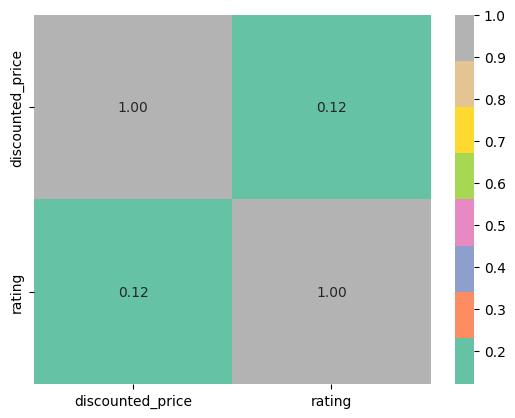

In [37]:
#Q8. What is the correlation between discounted_price and rating?

corr = df[['discounted_price', 'rating']].corr()
sns.heatmap(corr, annot = True, cmap = 'Set2', fmt = '.2f')

In [38]:
#Q9. What are the Top 5 categories based on the highest ratings?

category_ratings = df.groupby('category')['rating'].mean().sort_values(ascending = False).reset_index().head()
category_ratings

,category,rating
0,Computers&Accessories|Tablets,4.6
1,Computers&Accessories|NetworkingDevices|Networ...,4.5
2,Electronics|Cameras&Photography|Accessories|Film,4.5
3,Computers&Accessories|Components|Memory,4.5
4,Electronics|HomeAudio|MediaStreamingDevices|St...,4.5


In [39]:
df.head(1)

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,399.0,1099.0,64.0,4.2,24269.0,High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...


In [40]:
#Q10. Identify any potential areas for improvement or optimization based on the data analysis.

# Optimization >> category column should be sorted i.e. some precise categories

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://drive.google.com/uc?id=1JVgy2yXUOREkzRdCeWjep626uvvF94pP'

In [3]:
df = pd.read_csv(url)

In [4]:
df

,Artist,Track Name,Popularity,Duration (ms),Track ID
0,Drake,Rich Baby Daddy (feat. Sexyy Red & SZA),92,319191,1yeB8MUNeLo9Ek1UEpsyz6
1,Drake,One Dance,91,173986,1zi7xx7UVEFkmKfv06H8x0
2,Drake,IDGAF (feat. Yeat),90,260111,2YSzYUF3jWqb9YP9VXmpjE
3,Drake,First Person Shooter (feat. J. Cole),88,247444,7aqfrAY2p9BUSiupwk3svU
4,Drake,Jimmy Cooks (feat. 21 Savage),88,218364,3F5CgOj3wFlRv51JsHbxhe
...,...,...,...,...,...
435,French Montana,Splash Brothers,44,221863,3fBsEOnzwtlkpS0LxXAZhN
436,Fat Joe,All The Way Up (feat. Infared),64,191900,7Ezwtgfw7khBrpvaNPtMoT
437,A$AP Ferg,"Work REMIX (feat. A$AP Rocky, French Montana, ...",69,283693,7xVLFuuYdAvcTfcP3IG3dS
438,Diddy,Another One Of Me (feat. 21 Savage),65,220408,4hGmQboiou09EwhcTWa0H6


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         440 non-null    object
 1   Track Name     440 non-null    object
 2   Popularity     440 non-null    int64 
 3   Duration (ms)  440 non-null    int64 
 4   Track ID       440 non-null    object
dtypes: int64(2), object(3)
memory usage: 17.3+ KB


In [6]:
df.isnull().values.any()

np.False_

In [7]:
#Q1. Read the dataframe, check null value if present then do the needful, check duplicate row , if present then do the needful.

df.isnull().sum()

,0
Artist,0
Track Name,0
Popularity,0
Duration (ms),0
Track ID,0


In [8]:
df.duplicated().sum()

np.int64(27)

In [9]:
df.shape

(440, 5)

In [10]:
df.drop_duplicates(subset='Track ID', inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Popularity', ylabel='Count'>

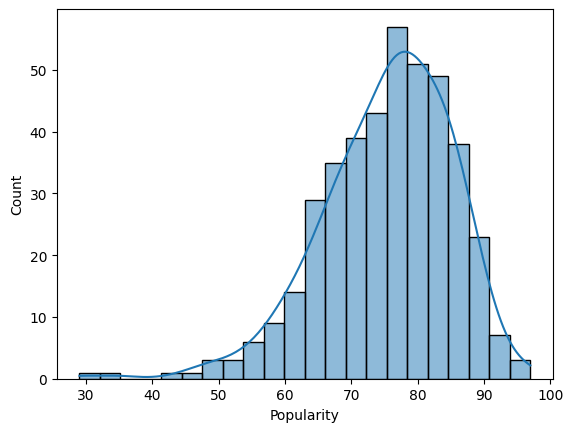

In [12]:
#Q2. What is the distribution of popularity among the tracks in the dataset? Visualize it using a histogram.

sns.histplot(x = 'Popularity', kde = True, data = df, palette = 'muted')

In [13]:
df['Duration'] = df['Duration (ms)']
df.drop('Duration (ms)', axis = 1, inplace = True)

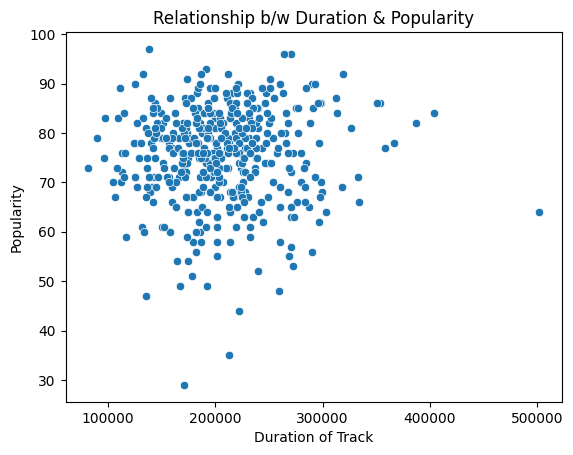

In [14]:
#Q3. Is there any relationship between the popularity and the duration of tracks? Explore this using a scatter plot.

sns.scatterplot(x = 'Duration', y = 'Popularity', data = df, palette = 'Set1')
plt.title('Relationship b/w Duration & Popularity')
plt.xlabel('Duration of Track')
plt.ylabel('Popularity')
plt.show()

In [16]:
#Q4. Which artist has the highest number of tracks in the dataset? Display the count of tracks for each artist using a countplot.

df['Artist'].value_counts().idxmax()

'Drake'

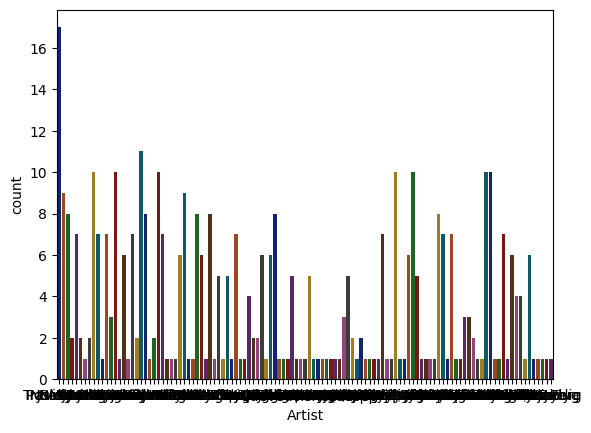

In [17]:
sns.countplot(x = 'Artist', data = df, palette = 'dark')
plt.show()

In [18]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Track ID', 'Duration'], dtype='object')

In [19]:
#Q5. What are the top 5 least popular tracks in the dataset? Provide the artist name and track name for each.

index = df['Popularity'].sort_values(ascending= False).tail().index
df.loc[index, ['Track Name', 'Artist']]

,Track Name,Artist
407,911 (feat. Mary J. Blige),Wyclef Jean
225,On Me - Remix,Lil Baby
413,Splash Brothers,French Montana
231,Intentions,Justin Bieber
207,Attachments (feat. Coi Leray),Pressa


In [15]:
df.columns

Index(['Artist', 'Track Name', 'Popularity', 'Track ID', 'Duration'], dtype='object')

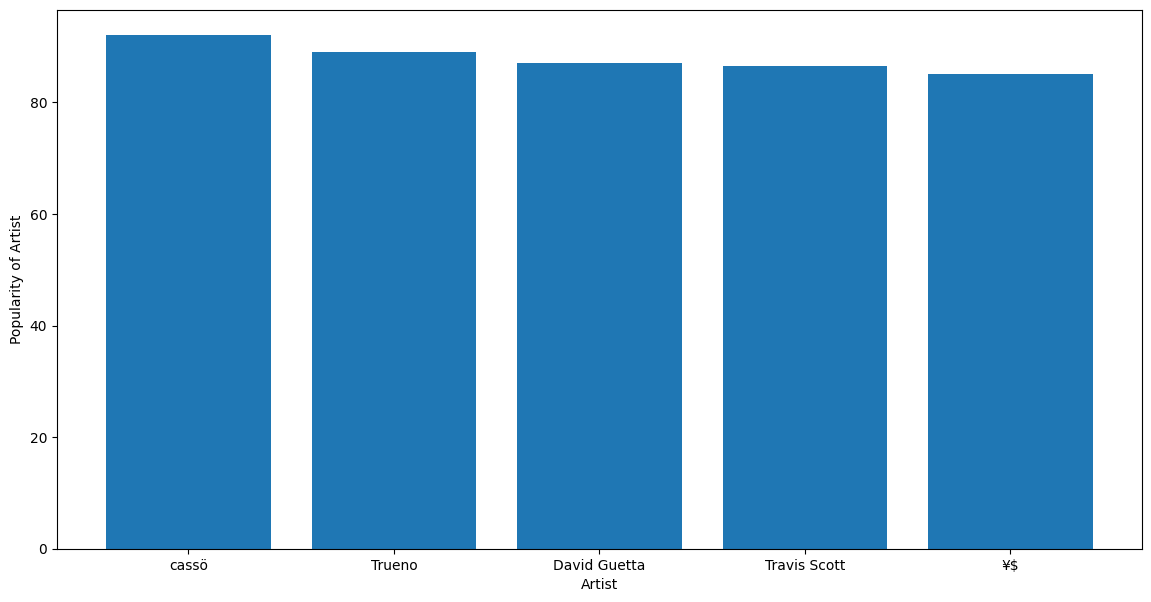

In [60]:
#Q6. Among the top 5 most popular artists, which artist has the highest popularity on average?
# Calculate and display the average popularity for each artist

top_5_artists = (df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5))

# highest_avg_popularity_artist = top_5_artists.idxmax()  #Artist
# highest_avg_popularity_value = top_5_artists.max()    #Value

plt.figure(figsize=(14,7))
plt.bar(top_5_artists.index, top_5_artists.values)
plt.xlabel('Artist')
plt.ylabel('Popularity of Artist')
plt.show()

In [66]:
# Q7. For the top 5 most popular artists, what are their most popular tracks? List the track name for each artist.

top_5_index = df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5).index
top_5_df = df[df['Artist'].isin(top_5_index)]
top_5_df[['Artist', 'Track Name']]

,Artist,Track Name
7,Travis Scott,MELTDOWN (feat. Drake)
30,Travis Scott,FE!N (feat. Playboi Carti)
31,Travis Scott,I KNOW ?
32,Travis Scott,MY EYES
33,Travis Scott,goosebumps
37,Travis Scott,SICKO MODE
38,Travis Scott,TELEKINESIS (feat. SZA & Future)
140,cassö,Prada
173,Travis Scott,SKITZO (feat. Young Thug)
200,David Guetta,Baby Don't Hurt Me


Text(0.5, 1.0, 'Pairplot')

<Figure size 1400x700 with 0 Axes>

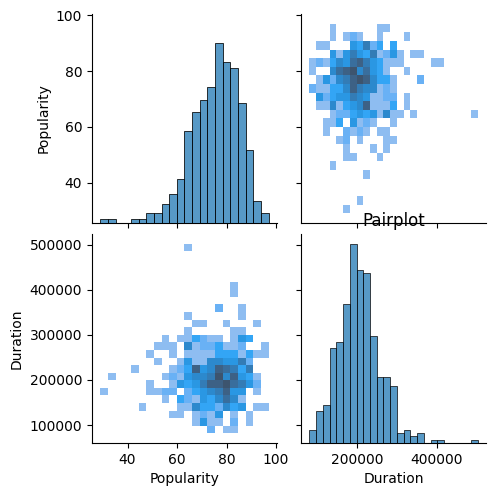

In [77]:
# Q8. Visualize relationships between multiple numerical variables simultaneously using a pair plot.

plt.figure(figsize=(14,7))
sns.pairplot(data = df, palette= 'muted', kind='hist', diag_kind='auto', markers= 'o')
plt.title('Pairplot')

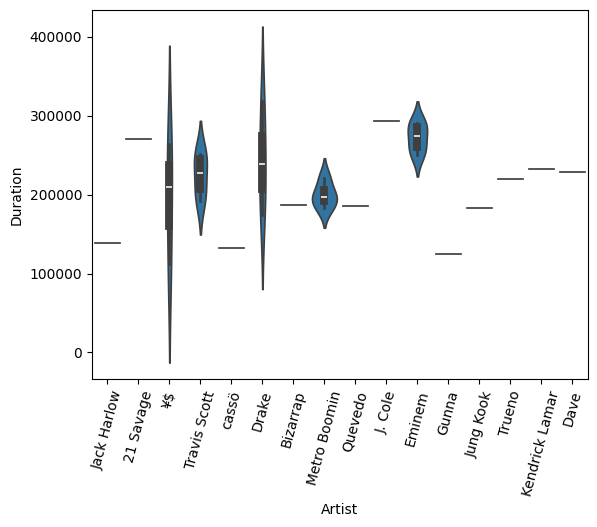

In [93]:
# Q9. Does the duration of tracks vary significantly across different artists? Explore this visually using a box plot or violin plot.

top_30_artist = df.groupby(['Artist', 'Duration'])['Popularity'].mean().sort_values(ascending= False).reset_index().head(30)
sns.violinplot(x = 'Artist', y = 'Duration', data = top_30_artist)
plt.xlabel("Artist")
plt.ylabel("Duration")
plt.xticks(rotation = 75)
plt.show()

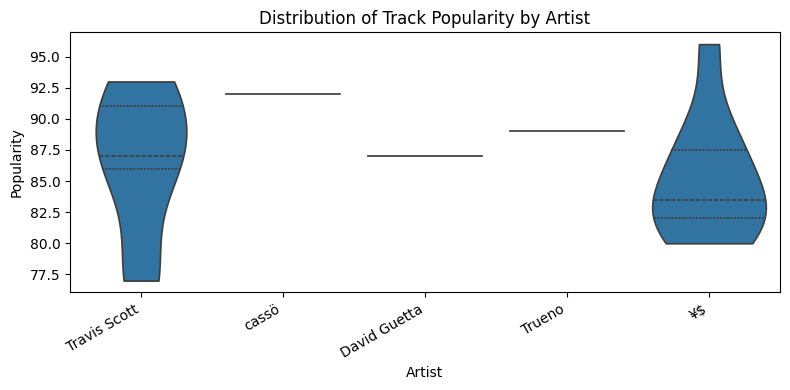

In [103]:
# Q10. How does the distribution of track popularity vary for different artists? Visualize this using a swarm plot or a violin plot

top_artists = (df.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5).index)
top_artists = df[df['Artist'].isin(top_artists)]

plt.figure(figsize=(8, 4))
sns.violinplot(data=top_artists, x='Artist', y='Popularity', inner='quartile', cut=0)
plt.xlabel('Artist')
plt.ylabel('Popularity')
plt.title('Distribution of Track Popularity by Artist')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

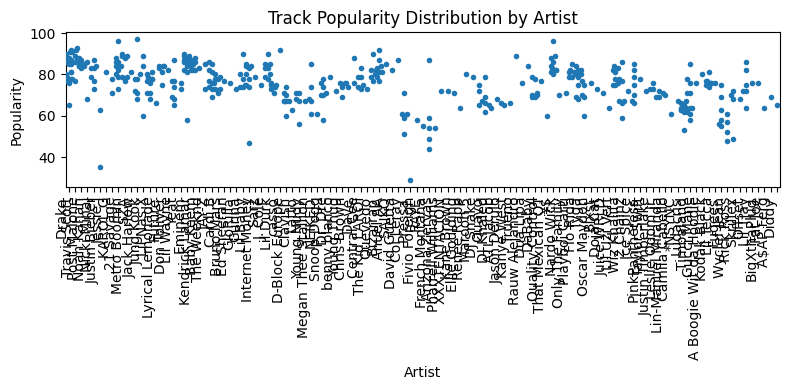

In [104]:
plt.figure(figsize=(8, 4))

sns.swarmplot(data=df, x='Artist', y='Popularity', size=4)
plt.xlabel('Artist')
plt.ylabel('Popularity')
plt.title('Track Popularity Distribution by Artist')
plt.xticks(rotation=90, ha='right')
plt.tight_layout()
plt.show()
